In [1]:
import sys
import os
from pathlib import Path

from section_identification.section_detector import automatic_identification

package_path = Path(os.path.abspath(""))
apply_filtering = True

example1 = package_path / "images/example1.png"
example2 = package_path / "images/example2.png"
example3 = package_path / "images/example3.png"
example4 = package_path / "images/example4.png"

# the weights can be downloaded from: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
checkpoint = package_path.parents[0] / "checkpoint/sam_vit_h_4b8939.pth" 


Image shape: (5000, 4916, 3)
Loaded cached masks.


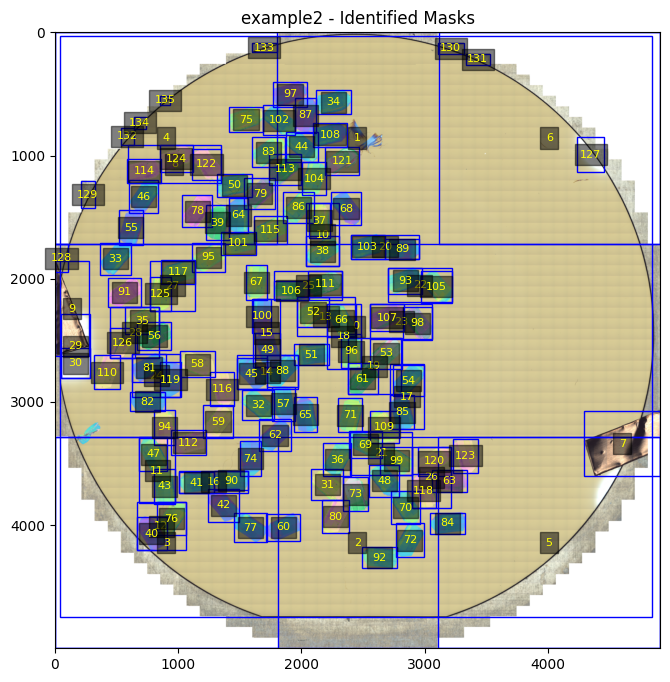

Time taken to run automatic_identification for example2.png: 1.62 seconds
Number of masks identified: 136


In [2]:
# Write filtering=True to only identify sections
masks = automatic_identification(example2, checkpoint=checkpoint, compress=False, apply_filtering=False, visualize=True)
print(f"Number of masks identified: {len(masks)}")

In [5]:
from section_identification.interactive import run_sam_interactive

new_masks, stored_masks, fiducials = run_sam_interactive(example4, checkpoint, masks, model_type="vit_h", device="cpu")

Quantized ONNX model already exists: /Users/fredericoaraujo/Documents/section_identification/images/example4_files/example4_onnx_quantized.onnx
[Info] Embedding already exists: /Users/fredericoaraujo/Documents/section_identification/images/example4_files/example4_embedding.npy
Image size: 5000x4999 (width x height), samScale: 0.205
[Info] Starting interactive segmentation. Move the mouse over the image to update mask.


2025-06-30 17:15:58.637 python[9922:776634] +[IMKClient subclass]: chose IMKClient_Modern
2025-06-30 17:15:58.637 python[9922:776634] +[IMKInputSession subclass]: chose IMKInputSession_Modern


[Info] Exiting interactive segmentation.


Exported mask coordinates to /Users/fredericoaraujo/Documents/section_identification/images/example4_files/example4_mask_coordinates.csv


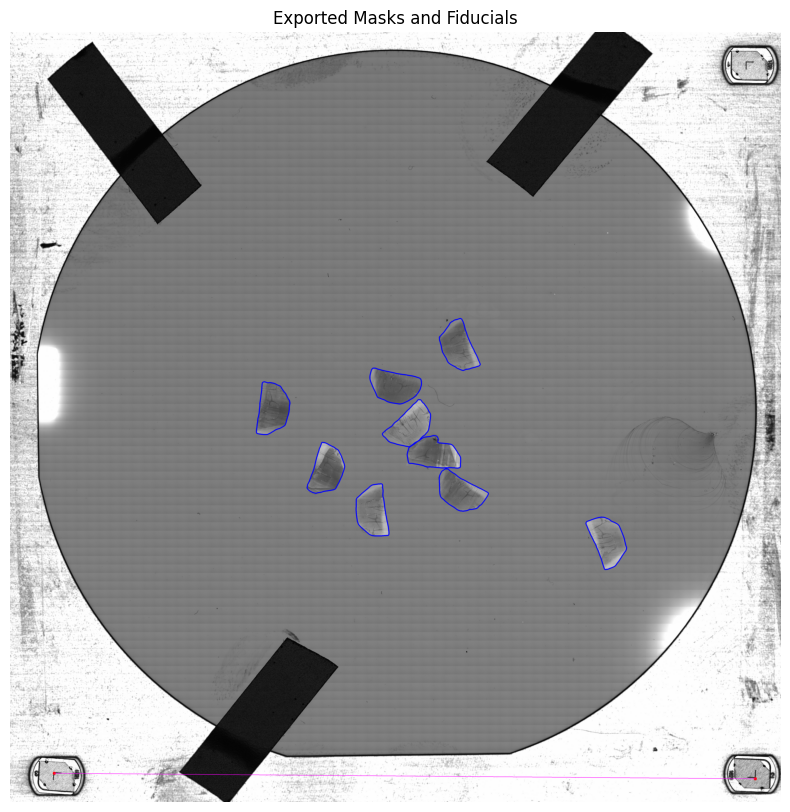

In [ ]:
from section_identification.export import export_mask_coordinates
csv_path = export_mask_coordinates(example4, new_masks, stored_masks, fiducials, visualize=True, sample_points=None)

In [15]:
from ruler import run_ruler


img_path = "/Users/fredericoaraujo/Documents/force_sensor/Data/Experiment 16/photos/1.png"
calibration_path_075 = "/Users/fredericoaraujo/Documents/force_sensor/Data/Measurements_calibration/0.75.png"
calibration_path_1 = "/Users/fredericoaraujo/Documents/force_sensor/Data/Measurements_calibration/1.0.png"
calibration_path_125 = "/Users/fredericoaraujo/Documents/force_sensor/Data/Measurements_calibration/1.25.png"
calibration_path_1_new = "/Users/fredericoaraujo/Documents/force_sensor/Data/Measurements_calibration/1.0_new.png"

magnification = 0.75  # e.g. 0.75x
original_length_mm = 7.595  # Original reference length in mm
measurements = run_ruler(img_path, magnification, original_length_mm)
print("Final Measurements:")
for meas in measurements:
    print(meas)

[Debug] Using calibrated scale: effective_pixels_per_mm = 93.96, conversion_factor = 0.010643 mm/pixel
[Info] Exiting ruler interface.
Final Measurements:
((611, 287), (1266, 391), 7.058376931483896, 0.9293452181018955)
((694, 604), (984, 670), 3.1653419990185934, 0.41676655681614133)
((592, 374), (1229, 552), 7.039190061211528, 0.926818967901452)


In [4]:
from section_identification.thesis import export_contour_image
export_contour_image(csv_path, example2)

NameError: name 'csv_path' is not defined

In [19]:
from section_identification.thesis import create_composite_image
# Set your folder paths
folder_before = "/Users/fredericoaraujo/Library/Mobile Documents/com~apple~CloudDocs/Harvard classes/ES 100/Image Library/Section_targeting/before_manual_detector"
folder_after  = "/Users/fredericoaraujo/Library/Mobile Documents/com~apple~CloudDocs/Harvard classes/ES 100/Image Library/Section_targeting/after_manual_detector"

# Create the composite image by calling the function
create_composite_image(folder_before, folder_after, output_filename="my_composite.jpg", max_rows=7)

Composite image saved as my_composite.jpg


Most common largest cluster size: 95 out of 136 total masks.
Chosen parameters: eps=540.0, min_samples=1


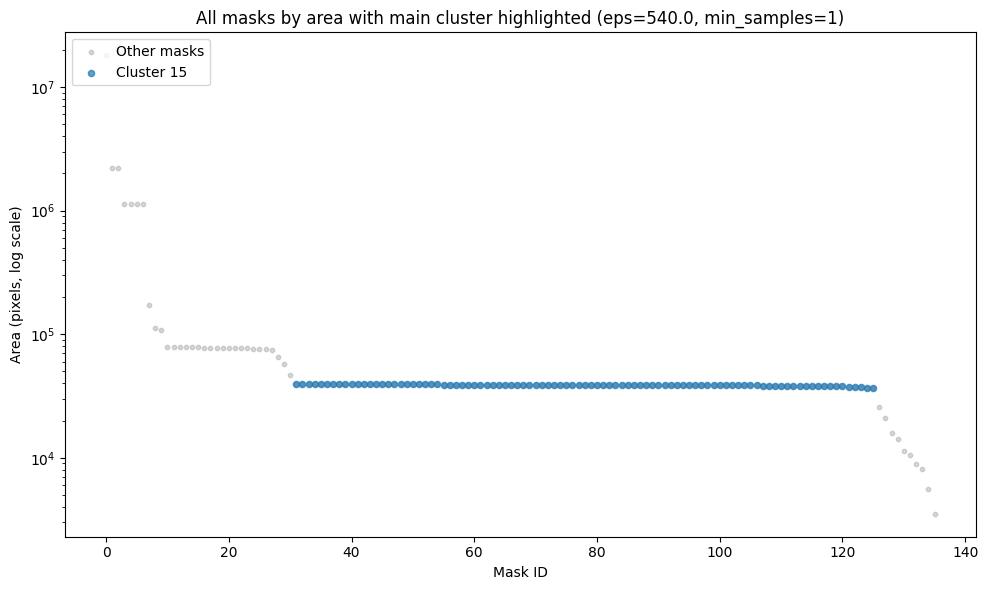

In [3]:
from section_identification.thesis import plot_mask_area_histogram

plot_mask_area_histogram('/Users/fredericoaraujo/Documents/section_identification/images/example2_files/example2_full_masks.pkl')